# Networks used in labs

In the labs, we build minimal networks with only a subset of the rates that can connect the nuclei.

## O+O rate

These nets all use an approximation to the O+O burning rate

In [1]:
import pynucastro as pyna
from pynucastro.rates.aprox_family_rates import make_CO_approx_rates

In [2]:
rl = pyna.ReacLibLibrary()
o_rates = make_CO_approx_rates(rl.get_rates(), "O")
o_rates

[O16 + O16 ⟶ S32 + 𝛾,
 S32 ⟶ O16 + O16,
 O16 + O16 ⟶ Si28 + He4,
 Si28 + He4 ⟶ O16 + O16,
 Si28 + He4 ⟶ S32 + 𝛾,
 S32 ⟶ Si28 + He4]

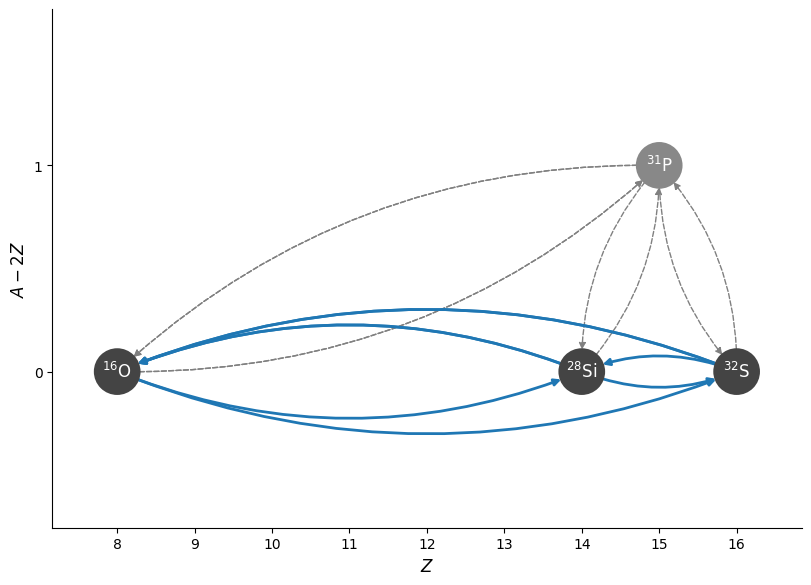

In [3]:
net = pyna.RateCollection(rates=o_rates)
fig = net.plot(rotated=True, curved_edges=True)

We see that we can go from ${}^{16}\mathrm{O}$ to ${}^{28}\mathrm{Si}$ either directly, or through ${}^{31}\mathrm{P}$.  We'll use an approximate rate that represents both of these paths

In [4]:
r1616 = net.get_rate_by_name("o16(o16,he4)si28")
r1616

O16 + O16 ⟶ Si28 + He4

In [5]:
type(r1616)

pynucastro.rates.approximate_rates.ApproximateRate

## Lab 1

We'll use the tabular rates from Suzuki

In [6]:
sl = pyna.SuzukiLibrary()

In [7]:
rate_names = ["ne20(,)f20",
              "f20(,)ne20",
              "f20(,)o20",
              "o20(,)f20"]
rates = sl.get_rate_by_name(rate_names)

In [8]:
net = pyna.RateCollection(rates=[r1616]+rates)

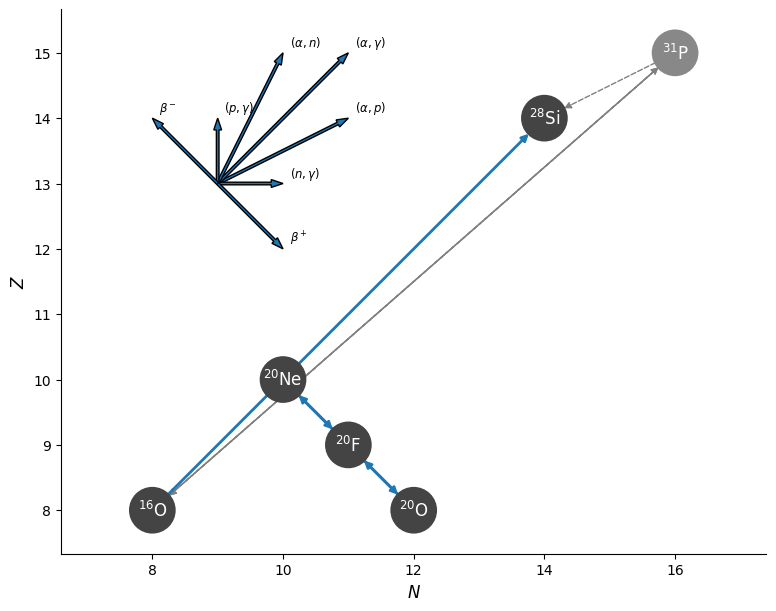

In [9]:
fig = net.plot(legend_coord=(13, 9))

## Lab 2

### first Urca pair

In [10]:
rate_names += ["na23(,)ne23",
               "ne23(,)na23"]
rates = sl.get_rate_by_name(rate_names)

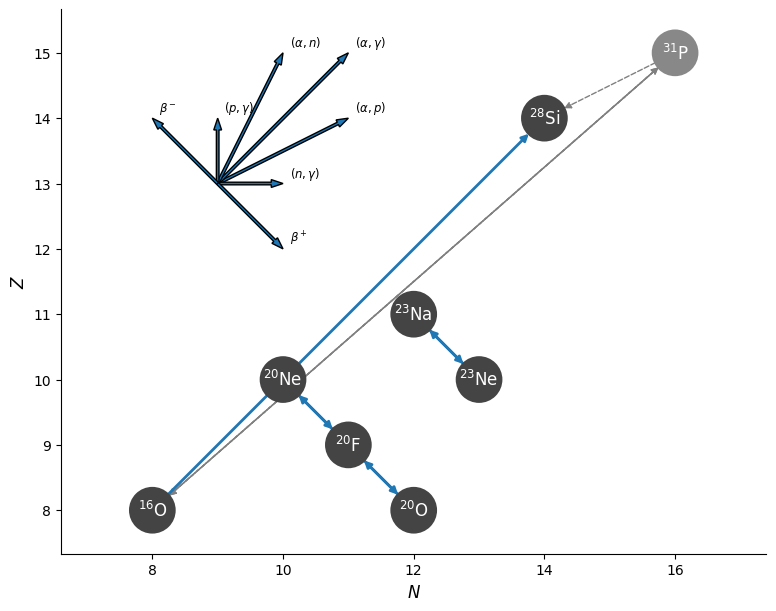

In [11]:
net = pyna.RateCollection(rates=[r1616]+rates)
fig = net.plot(legend_coord=(13, 9))

### second Urca pair

In [12]:
rate_names += ["mg25(,)na25",
               "na25(,)mg25"]
rates = sl.get_rate_by_name(rate_names)

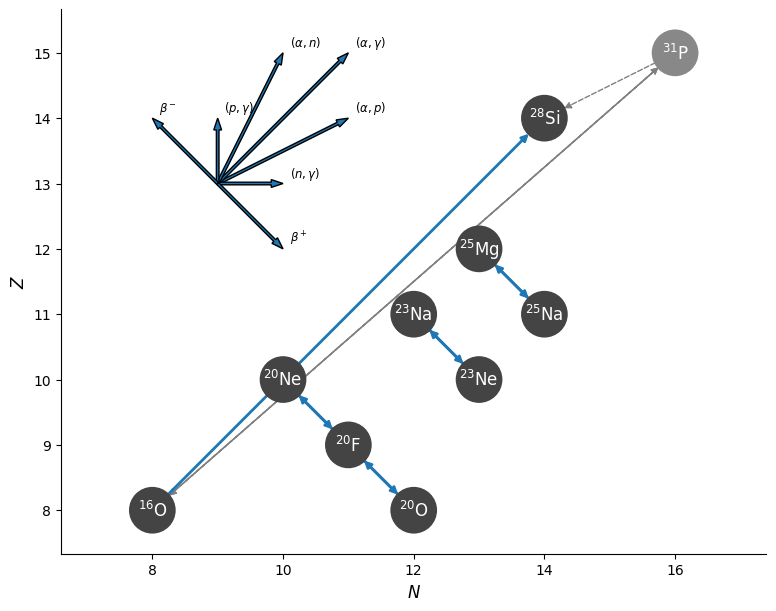

In [13]:
net = pyna.RateCollection(rates=[r1616]+rates)
fig = net.plot(legend_coord=(13, 9))

## Lab 3

We add a second $A=25$ urca pair and some $A = 24$ rates

In [14]:
rate_names += ["mg24(,)na24",
               "na24(,)mg24",
               "na24(,)ne24",
               "ne24(,)na24",
               "na25(,)ne25",
               "ne25(,)na25"]
rates = sl.get_rate_by_name(rate_names)

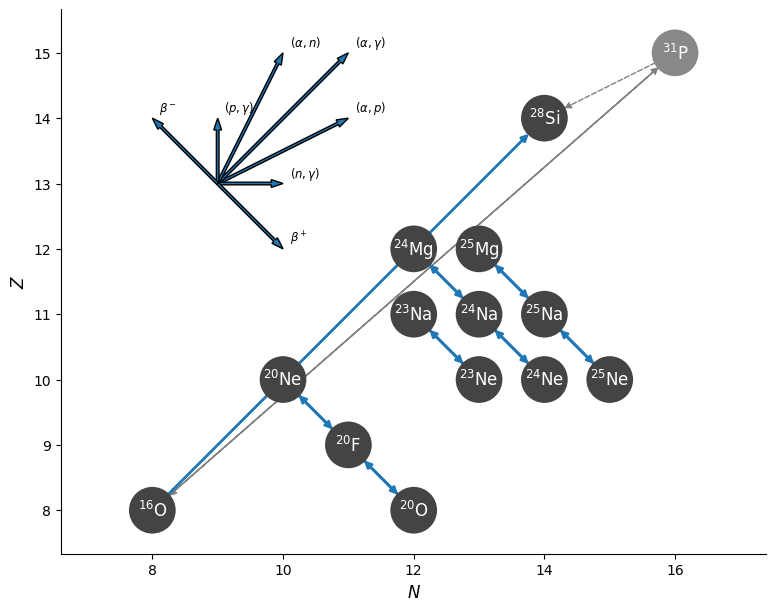

In [15]:
net = pyna.RateCollection(rates=[r1616]+rates)
fig = net.plot(legend_coord=(13, 9))